# The ML Process, Data, and Features

**Working Example.** Copy this file, rename it (replace _case with your alias), and modify your copy.

See docs/your-files.md for more information. 

Do not edit this example.
It should stay runnable and available as a reference
until after your work has been assessed. 

Your notebook should reflect your name (or alias), the date, your dataset, and your target in the opening below.

- Author: Denise Case
- Date: 2026-06
- Dataset: Seaborn Penguins
- Target: body_mass_g

Run all cells top to bottom (**Run All**) before pushing to GitHub.

## M2: Instructional Approach

Module 1 provided vocabulary and how to characterize an ML problem.

Module 2 presents the early stages of the process: assessing data and building features. 

Module 3 will begin the actual model-building.

## M2: Features

In this project, we construct **features** and report how they look. 

We learn how to decide whether a constructed feature is *useful* or *leakage*.

## Overview

This project uses the penguins dataset.
We choose to predict the target `body_mass_g`.
This target is a **numeric** variable (rather than a discrete category), so we have a:

- supervised ML problem (because we've chosen a target)
- a regression problem (because our target is numeric)

Customize the overview in your copy to reflect your dataset and choices.

## A. Prepare the Project Environment (.venv/)

- Open **only one project in VS Code at a time**.
- Prepare the .venv/: specify Python version and install / upgrade dependencies listed in `pyproject.toml`.
- Open an integrated terminal (PowerShell if Windows) in the **root project** folder and run:

```shell
uv self update
uv python pin 3.14
uv lock --upgrade
uv sync --extra dev --extra docs --upgrade
```


## B. Select the Notebook Kernel

- Click on the **Select Kernel** name in the top-right corner of the notebook interface.
- Choose Python Environments... /
- Choose the recommended local .venv/ from the drop-down menu.
- This will create a new kernel for the notebook and allow the notebook to use packages installed in the .venv/ environment.

## C. Working in Notebooks (Custom Notes)

- To run a cell, press **Ctrl+Enter** (or **Cmd+Enter** on Mac) when done editing the cell.
- Change the type of a cell (e.g., code or markdown) by looking in the lower left corner of the notebook interface.
- Rearrange cells by dragging and dropping them within the notebook.

See [Run Jupyter Notebooks](https://denisecase.github.io/pro-analytics-02/workflow-b-apply-example-project/run-notebook/) for:

- how to **copy a notebook**
- how to release a `project.log` file
- how to deal with a **stuck kernel**
- etc.

## M2. The Machine Learning Process

A typical ML project moves through stages. 
Earlier stages decide how well the later ones can possibly do.

Stages:

1. M1: **Frame** the question (what is the target; is ML a good tool).
2. M1: **Load** the data.
3. M2: **Assess** the data - is it useful, complete, representative?
4. M2:**Construct features** - shape the inputs the model will learn from. 
5. M3+: **Model** - fit an estimator. 
6. M3+: **Evaluate** - assess performance accurately.
7. M3+: **Use / serve** the model.

**Identifying useful data** means asking, before modeling: 

does this column carry information about the target, 
is it populated, 
and will it actually be available when a prediction is needed? 

A column that is mostly missing, or that is **only known after the outcome**, is not useful. 
This second case is called **leakage**.

**Constructing features** means deriving new inputs 
from existing columns (e.g., ratios, sums, bins, flags) 
that make the signal easier for a model to use. 

The danger is building a feature out of the target itself, 
which leaks the answer.

## Section 1. Project Setup and Imports

In [1]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M02", level="DEBUG")
log_header(LOG, "M02")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")


# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-07-12 00:07:14 | INFO | M02 | === RUN START ===
2026-07-12 00:07:14 | INFO | M02 | project=M02
2026-07-12 00:07:14 | INFO | M02 | repo_dir=ml-02-features
2026-07-12 00:07:14 | INFO | M02 | python=3.14.3
2026-07-12 00:07:14 | INFO | M02 | os=Windows 10
2026-07-12 00:07:14 | INFO | M02 | shell=powershell
2026-07-12 00:07:14 | INFO | M02 | cwd=notebooks
2026-07-12 00:07:14 | INFO | M02 | github_actions=False
2026-07-12 00:07:14 | INFO | M02 | Confirming installation:
2026-07-12 00:07:14 | INFO | M02 |   python:       3.14.3
2026-07-12 00:07:14 | INFO | M02 |   pandas:       3.0.3
2026-07-12 00:07:14 | INFO | M02 |   numpy:        2.5.1
2026-07-12 00:07:14 | INFO | M02 |   scikit-learn: 1.9.0
2026-07-12 00:07:14 | INFO | M02 |   seaborn:      0.13.2
2026-07-12 00:07:14 | INFO | M02 |   matplotlib:   3.11.0


## Section 2. Load the Data

In [2]:
# === Section 2. Load the Data ===

# We are loading data from Seaborn's built-in datasets,
# which are small datasets included with the Seaborn library
# for practice and demonstration purposes.
# They are listed above with sns.get_dataset_names().
# Experiment with different ones to see what they contain.
# You can also load from CSV files, databases, or APIs and process is similar.

# CUSTOM: In this example, I load a Seaborn dataset by name (no external CSV).
# Change to explore a different dataset.
DATASET_NAME: Final[str] = "penguins"

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = sns.load_dataset(DATASET_NAME)
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")

2026-07-12 00:07:14 | INFO | M02 | Loading dataset: penguins
2026-07-12 00:07:14 | INFO | M02 | Loaded: 344 rows (instances), 7 columns


## Section 3. Assess the Data

ANALYST CHOICE: 

Is a  column useful? 
This requires the analyst's judgement.

A column is "useful" only if it carries information about the target AND will be
available at prediction time. 

Code can report completeness and dtype; 
YOU decide which columns to keep, drop, or treat with suspicion.




In [3]:
# === Section 3. Assess the Data ===

# CUSTOM: ANALYST CHOICE - the column you intend to predict.
# Naming it now to watch for features that would leak it.

INTENDED_TARGET: Final[str] = "body_mass_g"
LOG.info(f"The intended target is '{INTENDED_TARGET}'.")
LOG.info("Any feature derived FROM the target would leak the answer. Avoid those.")


# Report facts an analyst needs to judge whether columns are useful.

# WHY: Missingness, type, and basic spread tell us whether a column can
# carry signal and whether it is populated enough to rely on.
# This code reports those facts; it does not decide which columns to keep.

LOG.info("Per-column completeness and type:")

n_rows: int = df.shape[0]

for col in df.columns:
    missing: int = int(df[col].isna().sum())
    pct_present: float = 100.0 * (n_rows - missing) / n_rows
    LOG.info(
        f"  {col:20s} {str(df[col].dtype):10s} present={pct_present:5.1f}%  missing={missing}"
    )

numeric_cols: list[str] = df.select_dtypes(include="number").columns.tolist()
LOG.info("Numeric summary (for spread / outliers):")
LOG.debug(f"\n{df[numeric_cols].describe()}")

2026-07-12 00:07:14 | INFO | M02 | The intended target is 'body_mass_g'.
2026-07-12 00:07:14 | INFO | M02 | Any feature derived FROM the target would leak the answer. Avoid those.
2026-07-12 00:07:14 | INFO | M02 | Per-column completeness and type:
2026-07-12 00:07:14 | INFO | M02 |   species              str        present=100.0%  missing=0
2026-07-12 00:07:14 | INFO | M02 |   island               str        present=100.0%  missing=0
2026-07-12 00:07:14 | INFO | M02 |   bill_length_mm       float64    present= 99.4%  missing=2
2026-07-12 00:07:14 | INFO | M02 |   bill_depth_mm        float64    present= 99.4%  missing=2
2026-07-12 00:07:14 | INFO | M02 |   flipper_length_mm    float64    present= 99.4%  missing=2
2026-07-12 00:07:14 | INFO | M02 |   body_mass_g          float64    present= 99.4%  missing=2
2026-07-12 00:07:14 | INFO | M02 |   sex                  str        present= 96.8%  missing=11
2026-07-12 00:07:14 | INFO | M02 | Numeric summary (for spread / outliers):
2026-07-1

## Section 4. Construct Features

ANALYST CHOICE

Construct features you believe carry signal. 

Do NOT build a feature out of the target (that is leakage). 

This example builds a size ratio and a size category.

We need to determine usefulness.

2026-07-12 00:07:14 | INFO | M02 | Constructing features (vectorized, none are derived from the target)
2026-07-12 00:07:14 | INFO | M02 | Added features: ['bill_ratio', 'flipper_cm', 'size_class', 'body_mass_kg']
2026-07-12 00:07:14 | DEBUG | M02 | Sample of constructed features:
2026-07-12 00:07:14 | DEBUG | M02 | 
   flipper_length_mm  bill_ratio  flipper_cm size_class  body_mass_kg
0              181.0    2.090909        18.1      small          3.75
1              186.0    2.270115        18.6      small          3.80
2              195.0    2.238889        19.5     medium          3.25
3                NaN         NaN         NaN        NaN           NaN
4              193.0    1.901554        19.3     medium          3.45


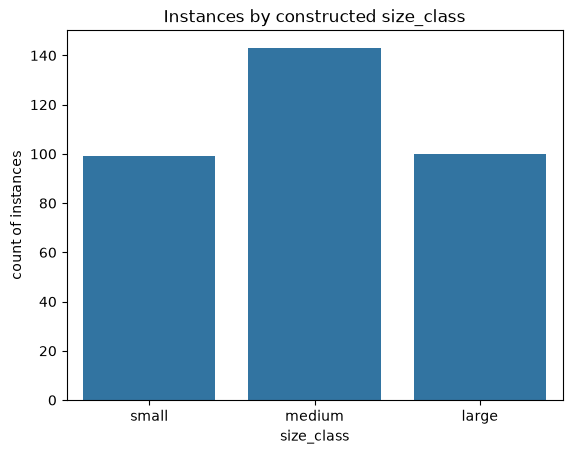

In [4]:
# === Section 4. Construct Features ===

"""Derive new features from existing columns (vectorized).

WHY: New inputs can make a real pattern easier for a model to use.
These operate on whole columns at once (no Python loop).
None of them is built from the intended target, so they cannot leak it.

Built here:
- bill_ratio: bill_length_mm / bill_depth_mm  (shape, unitless)
- flipper_cm: flipper_length_mm / 10            (rescaled)
- size_class: a category from flipper length    (binned)
- body_mass_kg: body_mass_g / 1000              (rescaled)

"""
LOG.info("Constructing features (vectorized, none are derived from the target)")

# Work on a copy so the original stays unchanged.
# Follow current pandas idiom:
# assign explicitly; avoid chained inplace, which silently does nothing
df_feat: pd.DataFrame = df.copy()

df_feat["bill_ratio"] = df_feat["bill_length_mm"] / df_feat["bill_depth_mm"]
df_feat["flipper_cm"] = df_feat["flipper_length_mm"] / 10.0
df_feat["body_mass_kg"] = df_feat["body_mass_g"] / 1000.0

# A categorical feature via binning. Bins are an ANALYST CHOICE.
df_feat["size_class"] = pd.cut(
    df_feat["flipper_length_mm"],
    bins=[0, 190, 210, np.inf],
    labels=["small", "medium", "large"],
)

new_cols: list[str] = ["bill_ratio", "flipper_cm", "size_class", "body_mass_kg"]

LOG.info(f"Added features: {new_cols}")

LOG.debug("Sample of constructed features:")
LOG.debug(f"\n{df_feat[['flipper_length_mm', *new_cols]].head()}")

# Show the new categorical feature.
# Visualize in every project.

plt.figure()
sns.countplot(data=df_feat, x="size_class")
plt.title("Instances by constructed size_class")
plt.xlabel("size_class")
plt.ylabel("count of instances")
plt.show()

## Section 5. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

In [5]:
# === Python Summary ===


"""Record where we are in the process and the judgment still owed."""
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset:          {DATASET_NAME}")
LOG.info(f"Original columns: {df.shape[1]}")
LOG.info(f"After features:   {df_feat.shape[1]}")
LOG.info(f"Intended target:  {INTENDED_TARGET}")
LOG.info("========================")

2026-07-12 00:07:14 | INFO | M02 | ========================
2026-07-12 00:07:14 | INFO | M02 | SUMMARY
2026-07-12 00:07:14 | INFO | M02 | ========================
2026-07-12 00:07:14 | INFO | M02 | Dataset:          penguins
2026-07-12 00:07:14 | INFO | M02 | Original columns: 7
2026-07-12 00:07:14 | INFO | M02 | After features:   11
2026-07-12 00:07:14 | INFO | M02 | Intended target:  body_mass_g
2026-07-12 00:07:14 | INFO | M02 | ========================



### Custom Narrative

Summarize your work in this Markdown cell in your notebook.

This is SUPERVISED learning (because the data includes a target).

The chosen target is `body_mass_g` and that is a continuous numeric variable. 

Therefore, modeling this problem will use **regression**.

### Custom Conclusions

UPDATE THESE REMARKS IN YOUR COPY: 

Which columns are genuinely useful, and which did you distrust? Why?"

Which constructed features do you expect to help, and why?"

Did you avoid leakage (no feature built from the target)?"

See README.md and docs/index.md for more. 

### Next Steps

Summarize your next steps in this Markdown cell in your notebook.

We have assessed data and built features. 

Next we will learn to fit a model. 


## Section 6. Creative Feature Visualization

Create a multi-dimensional visualization exploring feature relationships and save as an image artifact.


2026-07-12 00:16:31 | INFO | M02 | Creative visualization saved to: data\processed\penguin_feature_space.png


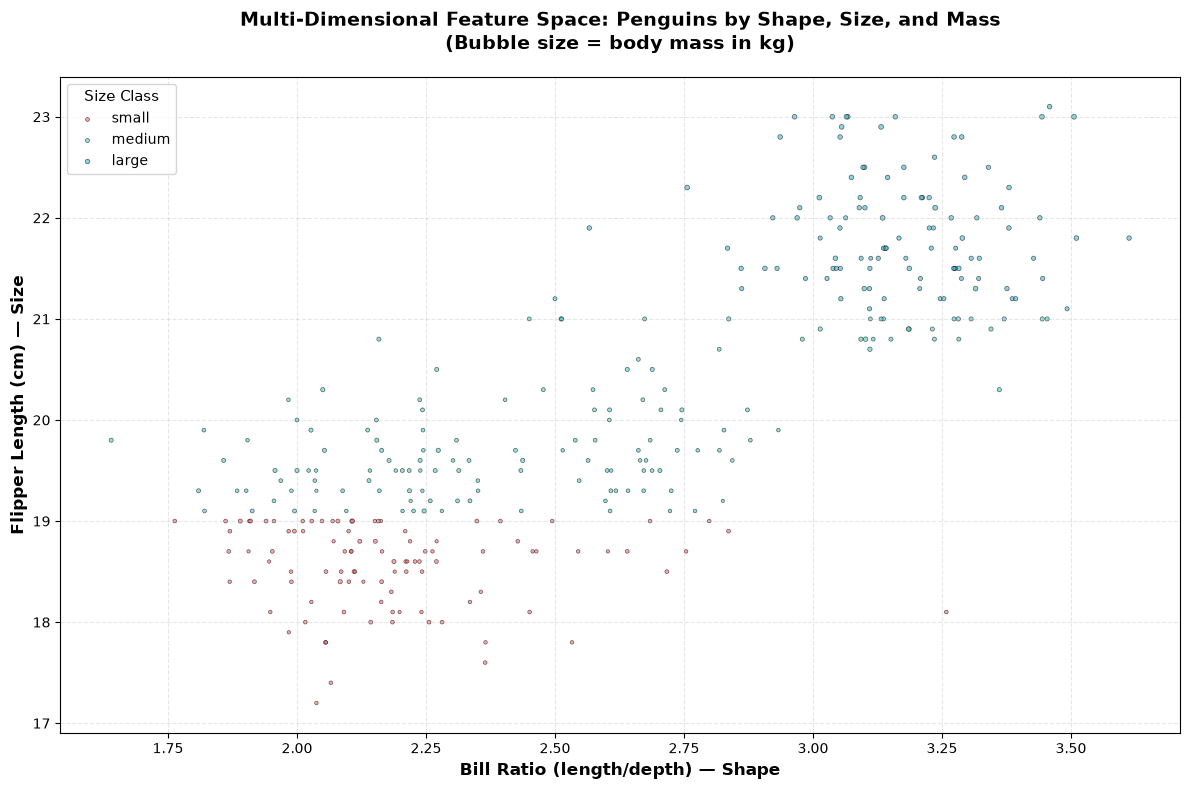

In [ ]:
# === Section 6. Creative Feature Visualization ===

from pathlib import Path

"""Create a multi-dimensional visualization combining multiple constructed features.

This bubble chart explores the relationship between:
- X-axis: bill_ratio (shape characteristic)
- Y-axis: flipper_cm (size characteristic)
- Bubble size: body_mass_kg (target variable)
- Color: size_class (categorical grouping)

This visualization reveals feature correlations and distributional patterns.
"""

# Create output directory if it doesn't exist
output_dir = Path("data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

# Create the multi-dimensional bubble chart
fig, ax = plt.subplots(figsize=(12, 8))

# Define color palette for size_class
colors = {"small": "#FF6B6B", "medium": "#4ECDC4", "large": "#45B7D1"}

# Plot each size_class separately for better legend
for size_class in ["small", "medium", "large"]:
    mask = df_feat["size_class"] == size_class
    subset = df_feat[mask]

    scatter = ax.scatter(
        subset["bill_ratio"],
        subset["flipper_cm"],
        s=subset["body_mass_kg"] * 2,  # Scale for visibility
        alpha=0.6,
        c=colors[size_class],
        label=size_class,
        edgecolors="black",
        linewidth=0.5,
    )

ax.set_xlabel("Bill Ratio (length/depth) — Shape", fontsize=12, fontweight="bold")
ax.set_ylabel("Flipper Length (cm) — Size", fontsize=12, fontweight="bold")
ax.set_title(
    "Multi-Dimensional Feature Space: Penguins by Shape, Size, and Mass\n(Bubble size = body mass in kg)",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
ax.legend(title="Size Class", title_fontsize=11, fontsize=10, loc="best")
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()

# Save the figure
output_path = output_dir / "penguin_feature_space.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
LOG.info(f"Creative visualization saved to: {output_path}")

plt.show()

## Task: Make the Notebook Yours (Apply / Extend / Explore)

This is an example.
Copy this notebook and make it your own. 

In your copy:

1. At the beginning, update the Author, the purpose, the target, etc. 
2. Remove any instructions you do not need. 

Try things like the following.

1. **Apply** - Swap `DATASET_NAME` to `"tips"` or your own CSV in `data/raw/` and
   assess the data. Decide which columns are useful and say why.
2. **Extend** - Construct two new features the example does not build. Justify each,
   and confirm neither is derived from `INTENDED_TARGET`.
3. **Explore** - Deliberately build a leaking feature (e.g., a copy of the target
   with noise), observe that it looks "too good," and explain in `docs/index.md`
   why leakage is dangerous precisely because it looks helpful.

## Task: Finalize Your README.md

Include in README.md:

- your project description
- any instructions
- your commands
- a link to key artifacts (including your executed notebook)

When done, you may delete this instruction in your custom notebook.


## Task: Finalize your docs/index.md

In your docs/index.md, include things like:

- Your target.
- Why predicting this target could be useful and for whom.
- Whether ML is a good tool for this problem and why or why not. 
- For example, would a simple rule work better?
- Which features look informative, and which look irrelevant.
- What might 'good enough' mean for this question.

Important:

- There is no threshold that answers these questions automatically.
- Use notebook, README.md, and docs/index.md to share your judgement and your ML skills.


## Task: Final Check

- `README.md` - reflects your description, instructions, commands, and links to your executed notebook.
- `docs/index.md` - reflects your project-specific updates.
- Your GitHub **About** section has a link to your hosted documentation site.
- The executed example notebook AND your custom notebook are available in `notebooks/`.
- Keep this **working example** alongside your custom work until your work has been assessed.
- Ensure your **custom notebook** introduces and narrates **your** custom project.

## Reminder: Run All before pushing to GitHub

Before saving a notebook (and running git add-commit-push), click 'Run All' to generate all outputs and display them in the notebook.

Follow our [pro-analytics-02](https://denisecase.github.io/pro-analytics-02/) common workflows.

Your README.md should have a description, a link to your executed notebook, and a list of commands (updated as you add your custom description, instructions, and commands).

Your docs/ folder should document your custom project analysis in the `docs/index.md` summary.
